In [1]:
# ===== IMMUNOSENSE: LEVEL 1 — BIOMARKER EXPLORATION =====
# Understanding what autoimmune disease looks like in lab values
# Before any ML, before any agents — pure data exploration
#
# Datasets:
#   1. Rheumatic 2025 (12,085 patients, 6 diseases + healthy)
#   2. NHANES (10K+ Americans, CRP + demographics + BMI + CBC)
#
# Questions we're answering:
#   - What biomarkers distinguish RA from Lupus from Healthy?
#   - What does "normal" CRP look like across age/sex/BMI?
#   - Which biomarkers are most discriminative?
#   - How much overlap exists between diseases?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

print("="*60)
print("IMMUNOSENSE — LEVEL 1: BIOMARKER EXPLORATION")
print("="*60)

# ===== LOAD RHEUMATIC DATASET =====
print("\n[1/2] Loading Rheumatic & Autoimmune Disease Dataset...")
df_rh = pd.read_excel(r'C:\Projects\immunosense\data\rheumatic\Rheumatic and Autoimmune Disease Dataset.xlsx')

print(f"  Shape: {df_rh.shape}")
print(f"  Columns: {list(df_rh.columns)}")
print(f"\n  First 3 rows:")
print(df_rh.head(3).to_string())
print(f"\n  Data types:")
print(df_rh.dtypes)
print(f"\n  Missing values:")
print(df_rh.isnull().sum())

# ===== LOAD NHANES =====
print("\n[2/2] Loading NHANES datasets...")

# CRP
df_crp = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\HSCRP_L.XPT')
print(f"  CRP: {df_crp.shape} — columns: {list(df_crp.columns)}")

# Demographics
df_demo = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\DEMO_L.XPT')
print(f"  Demographics: {df_demo.shape}")

# BMI
df_bmx = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\BMX_L.XPT')
print(f"  Body Measures: {df_bmx.shape}")

# CBC
df_cbc = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\CBC_L.XPT')
print(f"  CBC: {df_cbc.shape}")

# Merge NHANES on SEQN (patient ID)
df_nhanes = df_crp.merge(df_demo[['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3']], on='SEQN', how='inner')
df_nhanes = df_nhanes.merge(df_bmx[['SEQN','BMXBMI']], on='SEQN', how='left')
df_nhanes = df_nhanes.merge(df_cbc[['SEQN','LBXWBCSI','LBXLYPCT','LBXNEPCT','LBXPLTSI']], on='SEQN', how='left')

# Rename for clarity
df_nhanes = df_nhanes.rename(columns={
    'LBXHSCRP': 'CRP',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Sex',
    'RIDRETH3': 'Race',
    'BMXBMI': 'BMI',
    'LBXWBCSI': 'WBC',
    'LBXLYPCT': 'Lymphocyte_pct',
    'LBXNEPCT': 'Neutrophil_pct',
    'LBXPLTSI': 'Platelets',
})

# Sex: 1=Male, 2=Female
df_nhanes['Sex_label'] = df_nhanes['Sex'].map({1: 'Male', 2: 'Female'})

print(f"\n  Merged NHANES: {df_nhanes.shape}")
print(f"  CRP range: {df_nhanes['CRP'].min():.2f} — {df_nhanes['CRP'].max():.2f} mg/L")
print(f"  Age range: {df_nhanes['Age'].min():.0f} — {df_nhanes['Age'].max():.0f}")
print(f"  BMI range: {df_nhanes['BMI'].min():.1f} — {df_nhanes['BMI'].max():.1f}")

print("\n✅ Both datasets loaded successfully")
print(f"  Rheumatic: {len(df_rh)} patients, {df_rh.shape[1]} features")
print(f"  NHANES: {len(df_nhanes)} Americans, {df_nhanes.shape[1]} features")

IMMUNOSENSE — LEVEL 1: BIOMARKER EXPLORATION

[1/2] Loading Rheumatic & Autoimmune Disease Dataset...
  Shape: (12085, 15)
  Columns: ['Age', 'Gender', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm', 'C3', 'C4', 'Disease']

  First 3 rows:
   Age  Gender   ESR   CRP    RF  Anti-CCP   HLA-B27       ANA   Anti-Ro   Anti-La Anti-dsDNA   Anti-Sm     C3    C4               Disease
0   70    Male  39.0  18.6  34.2      29.9  Positive  Negative  Positive  Negative   Positive  Positive    NaN  27.0  Rheumatoid Arthritis
1   39  Female  26.0  21.7  35.5      28.9  Negative       NaN  Positive       NaN   Positive       NaN  100.0  66.0  Rheumatoid Arthritis
2   36  Female  41.0  15.6  21.3      21.3  Negative  Negative       NaN  Positive   Negative       NaN  158.0  12.0  Rheumatoid Arthritis

  Data types:
Age             int64
Gender            str
ESR           float64
CRP           float64
RF            float64
Anti-CCP      float64
HLA-B27 

In [2]:
# ===== DATASET OVERVIEW =====
print("="*60)
print("RHEUMATIC DATASET — DISEASE DISTRIBUTION")
print("="*60)
print(df_rh['Disease'].value_counts())
print(f"\nTotal patients: {len(df_rh)}")

print(f"\n{'='*60}")
print("RHEUMATIC — NUMERIC SUMMARY")
print("="*60)
print(df_rh[['Age','ESR','CRP','RF','Anti-CCP','C3','C4']].describe().round(2))

print(f"\n{'='*60}")
print("NHANES — SUMMARY")
print("="*60)
print(f"Total records: {len(df_nhanes)}")
print(f"Columns: {list(df_nhanes.columns)}")
print(f"\nCRP: {df_nhanes['CRP'].describe().round(2)}")
print(f"\nAge: {df_nhanes['Age'].describe().round(1)}")
print(f"\nBMI: {df_nhanes['BMI'].describe().round(1)}")
print(f"\nSex distribution:\n{df_nhanes['Sex_label'].value_counts()}")
print(f"\nMissing values:\n{df_nhanes.isnull().sum()}")

RHEUMATIC DATASET — DISEASE DISTRIBUTION
Disease
Rheumatoid Arthritis            2848
Ankylosing Spondylitis          2127
Sjögren's Syndrome              1852
Psoriatic Arthritis             1783
Normal                          1604
Systemic Lupus Erythematosus    1355
Reactive Arthritis               516
Name: count, dtype: int64

Total patients: 12085

RHEUMATIC — NUMERIC SUMMARY
            Age       ESR      CRP        RF  Anti-CCP        C3        C4
count  12085.00  10997.00  9668.00  10756.00   8822.00  10393.00  10031.00
mean      49.91     24.21    13.33     19.69     19.58    131.91     38.18
std       17.65     14.37    10.39     11.52     11.60     36.43     20.05
min       20.00      0.00     0.10      0.00      0.00     50.00      5.00
25%       35.00     10.00     1.90      9.70      9.50    105.00     21.00
50%       50.00     28.00    15.60     19.20     19.00    133.00     38.00
75%       65.00     36.00    22.60     29.70     29.60    161.00     55.00
max       80.0

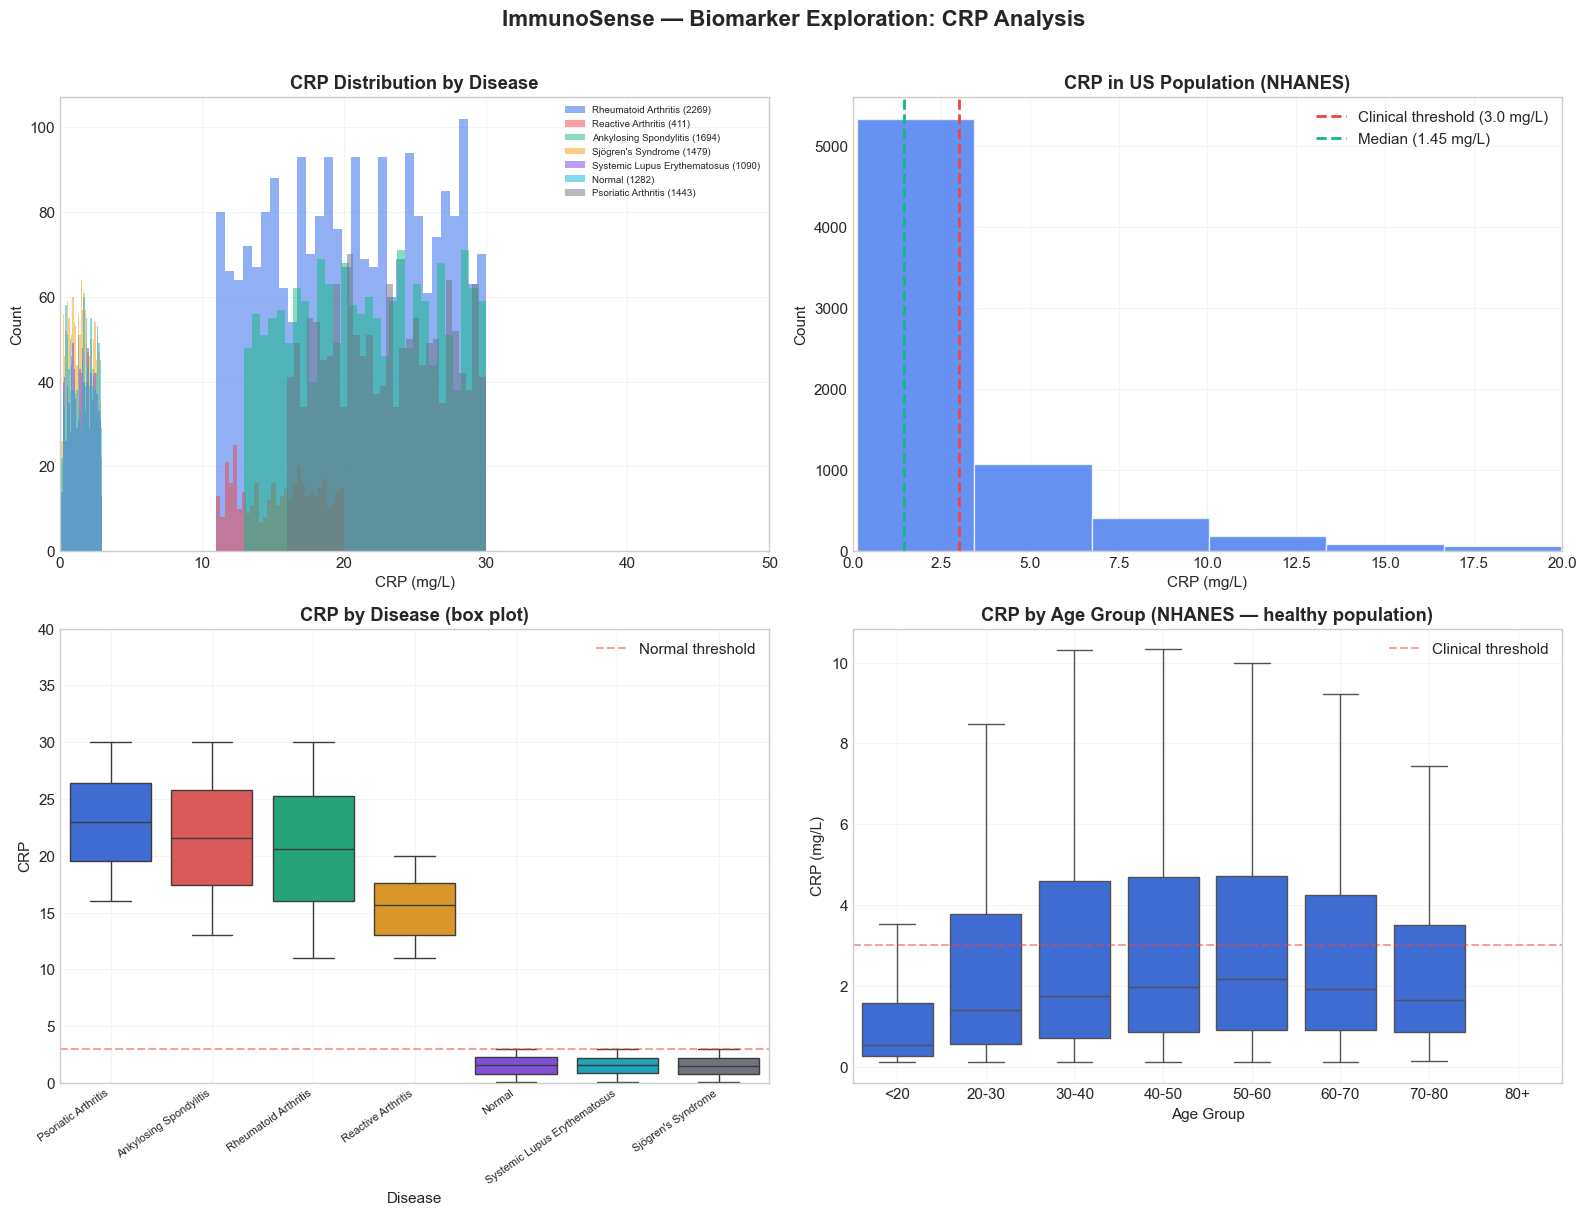


Key findings:
  NHANES median CRP (healthy): 1.45 mg/L
  NHANES % above 3.0 mg/L: 30.6%
  Rheumatic median CRP (diseased): 15.60 mg/L
  Separation: diseased CRP is 10.8x higher than healthy


In [3]:
# ===== VISUALIZATION 1: CRP DISTRIBUTION — DISEASE vs HEALTHY =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. CRP by disease (Rheumatic dataset)
ax1 = axes[0, 0]
diseases = df_rh['Disease'].unique()
colors = ['#2563eb', '#ef4444', '#10b981', '#f59e0b', '#7c3aed', '#06b6d4', '#6b7280']
for i, disease in enumerate(diseases):
    mask = df_rh['Disease'] == disease
    data = df_rh.loc[mask, 'CRP'].dropna()
    ax1.hist(data, bins=30, alpha=0.5, label=f'{disease} ({len(data)})', color=colors[i % len(colors)])
ax1.set_xlabel('CRP (mg/L)')
ax1.set_ylabel('Count')
ax1.set_title('CRP Distribution by Disease', fontweight='bold')
ax1.legend(fontsize=7)
ax1.set_xlim([0, 50])
ax1.grid(True, alpha=0.2)

# 2. CRP in healthy population (NHANES)
ax2 = axes[0, 1]
crp_clean = df_nhanes['CRP'].dropna()
ax2.hist(crp_clean, bins=50, color='#2563eb', alpha=0.7, edgecolor='white')
ax2.axvline(x=3.0, color='#ef4444', linestyle='--', linewidth=2, label='Clinical threshold (3.0 mg/L)')
ax2.axvline(x=crp_clean.median(), color='#10b981', linestyle='--', linewidth=2, label=f'Median ({crp_clean.median():.2f} mg/L)')
ax2.set_xlabel('CRP (mg/L)')
ax2.set_ylabel('Count')
ax2.set_title('CRP in US Population (NHANES)', fontweight='bold')
ax2.set_xlim([0, 20])
ax2.legend()
ax2.grid(True, alpha=0.2)

# 3. CRP by disease — box plot
ax3 = axes[1, 0]
order = df_rh.groupby('Disease')['CRP'].median().sort_values(ascending=False).index
sns.boxplot(data=df_rh, x='Disease', y='CRP', ax=ax3, palette=colors, order=order, showfliers=False)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax3.axhline(y=3.0, color='#ef4444', linestyle='--', alpha=0.5, label='Normal threshold')
ax3.set_title('CRP by Disease (box plot)', fontweight='bold')
ax3.set_ylim([0, 40])
ax3.legend()
ax3.grid(True, alpha=0.2)

# 4. NHANES CRP by age group
ax4 = axes[1, 1]
df_nhanes['Age_group'] = pd.cut(df_nhanes['Age'], bins=[0, 20, 30, 40, 50, 60, 70, 80, 100],
                                 labels=['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+'])
sns.boxplot(data=df_nhanes, x='Age_group', y='CRP', ax=ax4, color='#2563eb', showfliers=False)
ax4.axhline(y=3.0, color='#ef4444', linestyle='--', alpha=0.5, label='Clinical threshold')
ax4.set_title('CRP by Age Group (NHANES — healthy population)', fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('CRP (mg/L)')
ax4.legend()
ax4.grid(True, alpha=0.2)

fig.suptitle('ImmunoSense — Biomarker Exploration: CRP Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey findings:")
print(f"  NHANES median CRP (healthy): {crp_clean.median():.2f} mg/L")
print(f"  NHANES % above 3.0 mg/L: {(crp_clean > 3).mean()*100:.1f}%")
print(f"  Rheumatic median CRP (diseased): {df_rh['CRP'].median():.2f} mg/L")
print(f"  Separation: diseased CRP is {df_rh['CRP'].median() / crp_clean.median():.1f}x higher than healthy")

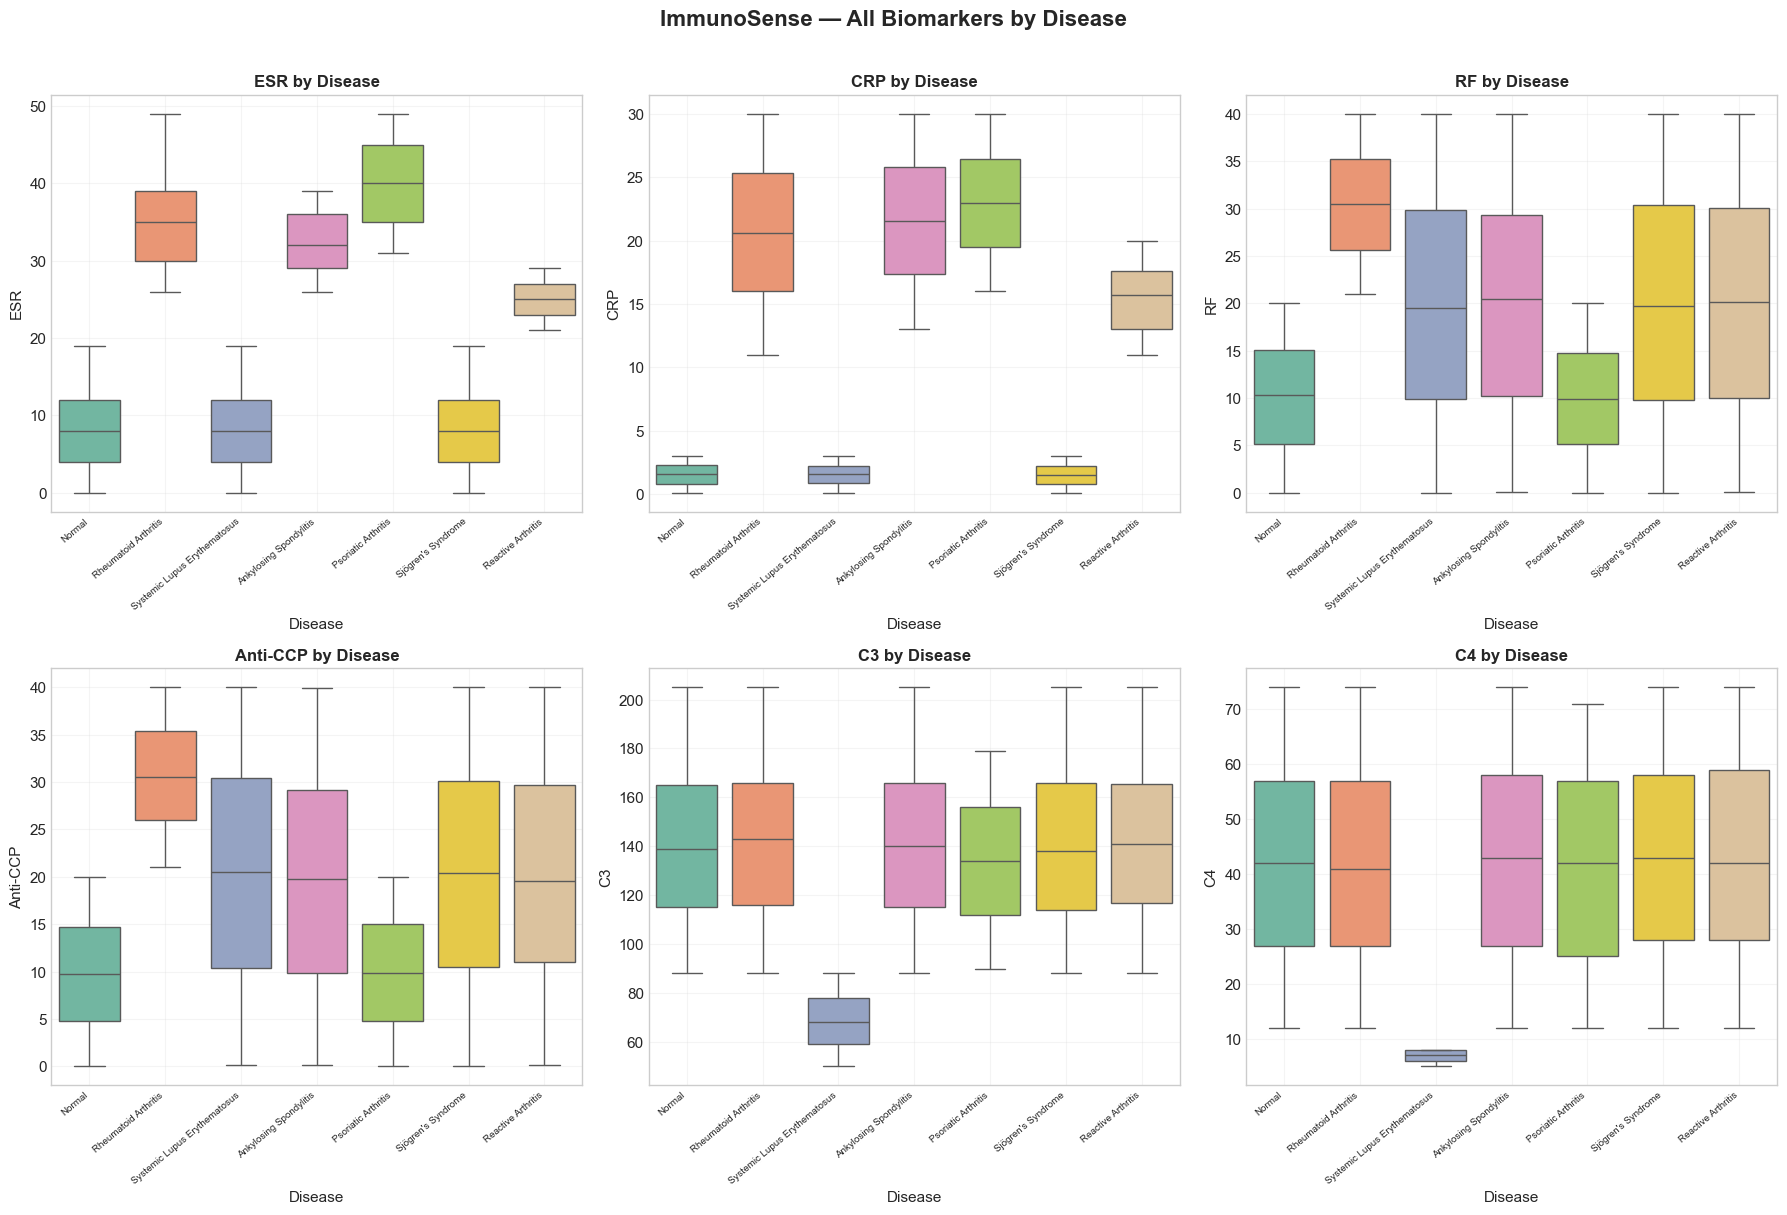


DISCRIMINATIVE POWER — Mean biomarker per disease
                                ESR    CRP     RF  Anti-CCP      C3     C4
Disease                                                                   
Ankylosing Spondylitis        32.35  21.58  20.00     19.70  140.88  42.78
Normal                         8.13   1.57  10.20      9.76  140.28  42.02
Psoriatic Arthritis           40.17  23.00   9.95      9.93  134.22  41.42
Reactive Arthritis            24.92  15.45  20.08     19.92  140.89  42.54
Rheumatoid Arthritis          35.09  20.62  30.37     30.58  141.93  41.97
Sjögren's Syndrome             8.19   1.51  20.05     20.15  140.61  42.51
Systemic Lupus Erythematosus   8.33   1.55  19.88     20.23   68.52   6.51


Key patterns:
  RA: High RF, High Anti-CCP, High CRP, High ESR
  SLE: High ANA (categorical), Low C3, Low C4, Anti-dsDNA+
  Ankylosing Spondylitis: HLA-B27+, High CRP, High ESR
  Normal: Low everything


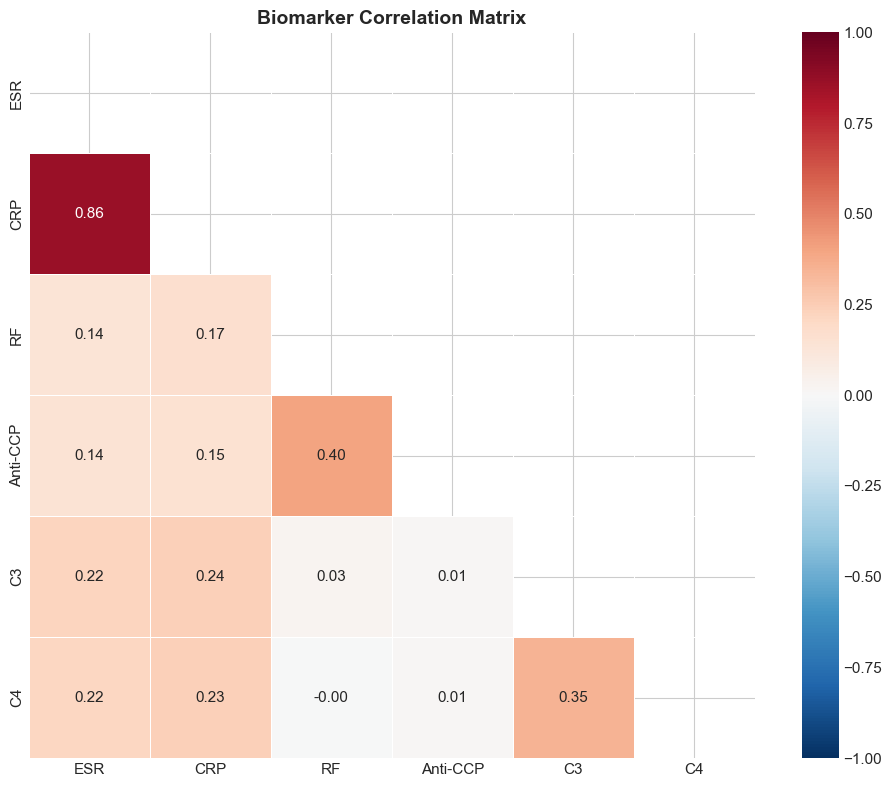


Strongest correlations:
  ESR ↔ CRP: 0.86
  RF ↔ Anti-CCP: 0.40
  C3 ↔ C4: 0.35


In [4]:
# ===== VISUALIZATION 2: ALL BIOMARKERS BY DISEASE =====
biomarkers = ['ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, bm in enumerate(biomarkers):
    ax = axes[i // 3, i % 3]
    order = ['Normal', 'Rheumatoid Arthritis', 'Systemic Lupus Erythematosus',
             'Ankylosing Spondylitis', 'Psoriatic Arthritis', "Sjögren's Syndrome", 'Reactive Arthritis']
    order = [d for d in order if d in df_rh['Disease'].unique()]
    
    sns.boxplot(data=df_rh, x='Disease', y=bm, ax=ax, palette='Set2', order=order, showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    ax.set_title(f'{bm} by Disease', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.2)

fig.suptitle('ImmunoSense — All Biomarkers by Disease', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ===== KEY INSIGHT: Which biomarkers discriminate which diseases? =====
print("\n" + "="*60)
print("DISCRIMINATIVE POWER — Mean biomarker per disease")
print("="*60)

pivot = df_rh.groupby('Disease')[biomarkers].mean().round(2)
print(pivot.to_string())

print("\n\nKey patterns:")
print("  RA: High RF, High Anti-CCP, High CRP, High ESR")
print("  SLE: High ANA (categorical), Low C3, Low C4, Anti-dsDNA+")
print("  Ankylosing Spondylitis: HLA-B27+, High CRP, High ESR")
print("  Normal: Low everything")

# ===== CORRELATION MATRIX =====
fig2, ax2 = plt.subplots(figsize=(10, 8))
corr = df_rh[biomarkers].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax2.set_title('Biomarker Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nStrongest correlations:")
for i in range(len(biomarkers)):
    for j in range(i+1, len(biomarkers)):
        c = corr.iloc[i, j]
        if abs(c) > 0.3:
            print(f"  {biomarkers[i]} ↔ {biomarkers[j]}: {c:.2f}")

LAYER 1: TRAINING POPULATION BASELINE MODEL

Training data: 7110 records
CRP range: 0.11 — 48.97 mg/L

Training 7 quantile models...
  Quantile 0.10: predicted threshold = 0.64 mg/L, actual coverage = 0.11
  Quantile 0.25: predicted threshold = 1.08 mg/L, actual coverage = 0.26
  Quantile 0.50: predicted threshold = 1.97 mg/L, actual coverage = 0.52
  Quantile 0.75: predicted threshold = 3.48 mg/L, actual coverage = 0.73
  Quantile 0.90: predicted threshold = 6.07 mg/L, actual coverage = 0.88
  Quantile 0.95: predicted threshold = 8.46 mg/L, actual coverage = 0.93
  Quantile 0.99: predicted threshold = 15.43 mg/L, actual coverage = 0.98

✅ All quantile models trained

TESTING: CRP predictions for different demographics

Patient                               10th   25th   50th   75th   90th   95th
-------------------------------------------------------------------------------------
25-year-old female, BMI 22            0.29   0.45   0.58   1.09   2.58   5.13
25-year-old male, BMI 22    

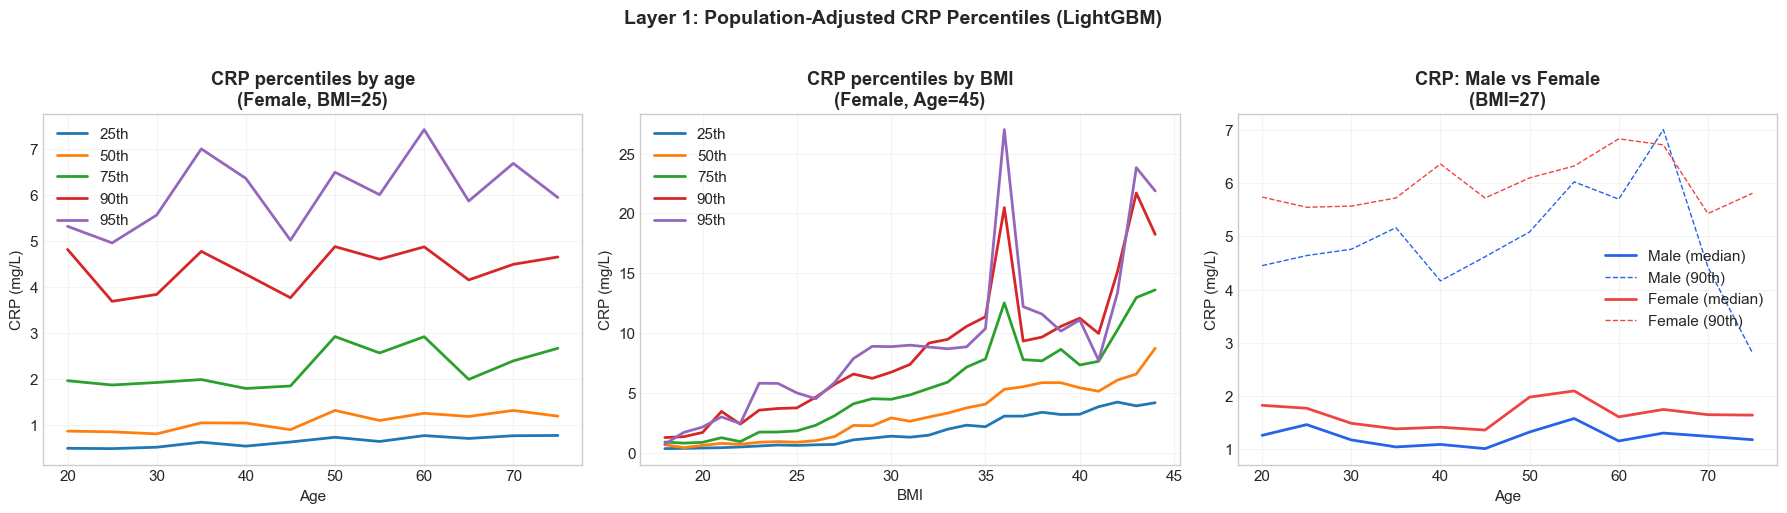


✅ LAYER 1 COMPLETE — Population baseline model trained
  Models: 7 quantile regressors
  Training data: 5688 NHANES records
  Features: Age, Sex, BMI → CRP distribution
  Inference time: <0.1ms per query


In [5]:
# ===== LAYER 1: POPULATION BASELINE — LightGBM Quantile Regression =====
# Train on NHANES: given (age, sex, BMI) → predict CRP distribution
# This teaches the system: "What is NORMAL CRP for this demographic?"

import lightgbm as lgb
from sklearn.model_selection import train_test_split

print("="*60)
print("LAYER 1: TRAINING POPULATION BASELINE MODEL")
print("="*60)

# Prepare NHANES data
df_train = df_nhanes[['Age', 'Sex', 'BMI', 'CRP', 'WBC']].dropna().copy()
df_train = df_train[df_train['CRP'] > 0]  # Remove zeros
df_train = df_train[df_train['CRP'] < 50]  # Remove extreme outliers

print(f"\nTraining data: {len(df_train)} records")
print(f"CRP range: {df_train['CRP'].min():.2f} — {df_train['CRP'].max():.2f} mg/L")

X = df_train[['Age', 'Sex', 'BMI']].values
y = df_train['CRP'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train one model per quantile
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
models = {}

print(f"\nTraining {len(quantiles)} quantile models...")
for q in quantiles:
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=200,
        num_leaves=31,
        learning_rate=0.05,
        min_child_samples=20,
        verbose=-1,
    )
    model.fit(X_train, y_train)
    models[q] = model
    
    # Evaluate on test set
    preds = model.predict(X_test)
    coverage = (y_test <= preds).mean()
    print(f"  Quantile {q:.2f}: predicted threshold = {preds.mean():.2f} mg/L, actual coverage = {coverage:.2f}")

print("\n✅ All quantile models trained")

# ===== TEST: What does the model say for different demographics? =====
print(f"\n{'='*60}")
print("TESTING: CRP predictions for different demographics")
print("="*60)

test_patients = [
    {"desc": "25-year-old female, BMI 22", "features": [25, 2, 22]},
    {"desc": "25-year-old male, BMI 22", "features": [25, 1, 22]},
    {"desc": "45-year-old female, BMI 28", "features": [45, 2, 28]},
    {"desc": "45-year-old male, BMI 32", "features": [45, 1, 32]},
    {"desc": "65-year-old female, BMI 30", "features": [65, 2, 30]},
    {"desc": "65-year-old male, BMI 25", "features": [65, 1, 25]},
]

print(f"\n{'Patient':<35s} {'10th':>6s} {'25th':>6s} {'50th':>6s} {'75th':>6s} {'90th':>6s} {'95th':>6s}")
print("-" * 85)

for patient in test_patients:
    x = np.array([patient['features']])
    preds = {q: models[q].predict(x)[0] for q in quantiles}
    print(f"{patient['desc']:<35s} {preds[0.10]:>6.2f} {preds[0.25]:>6.2f} {preds[0.50]:>6.2f} {preds[0.75]:>6.2f} {preds[0.90]:>6.2f} {preds[0.95]:>6.2f}")

# ===== FUNCTION: Get percentile for a patient =====
def get_crp_percentile(age, sex, bmi, crp_value):
    """Given demographics and a CRP value, return the percentile."""
    x = np.array([[age, sex, bmi]])
    for q in sorted(quantiles):
        threshold = models[q].predict(x)[0]
        if crp_value <= threshold:
            return q
    return 0.99

# Test the function
print(f"\n{'='*60}")
print("PERCENTILE LOOKUP EXAMPLES")
print("='*60")
print(f"\n  CRP=4.0, 25F BMI=22 → {get_crp_percentile(25, 2, 22, 4.0)*100:.0f}th percentile (ALARMING)")
print(f"  CRP=4.0, 45M BMI=32 → {get_crp_percentile(45, 1, 32, 4.0)*100:.0f}th percentile (mildly elevated)")
print(f"  CRP=1.0, 25F BMI=22 → {get_crp_percentile(25, 2, 22, 1.0)*100:.0f}th percentile (normal)")
print(f"  CRP=8.0, 65F BMI=30 → {get_crp_percentile(65, 2, 30, 8.0)*100:.0f}th percentile (elevated)")

# ===== VISUALIZE: CRP distribution by demographic =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CRP percentiles by age (female, BMI=25)
ages = range(20, 80, 5)
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    vals = [models[q].predict([[a, 2, 25]])[0] for a in ages]
    axes[0].plot(ages, vals, label=f'{int(q*100)}th', linewidth=2)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('CRP (mg/L)')
axes[0].set_title('CRP percentiles by age\n(Female, BMI=25)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Plot 2: CRP percentiles by BMI (45-year-old female)
bmis = range(18, 45)
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    vals = [models[q].predict([[45, 2, b]])[0] for b in bmis]
    axes[1].plot(bmis, vals, label=f'{int(q*100)}th', linewidth=2)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('CRP (mg/L)')
axes[1].set_title('CRP percentiles by BMI\n(Female, Age=45)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# Plot 3: Male vs Female CRP (BMI=27)
for sex, label, color in [(1, 'Male', '#2563eb'), (2, 'Female', '#ef4444')]:
    vals = [models[0.50].predict([[a, sex, 27]])[0] for a in ages]
    axes[2].plot(ages, vals, label=f'{label} (median)', linewidth=2, color=color)
    vals90 = [models[0.90].predict([[a, sex, 27]])[0] for a in ages]
    axes[2].plot(ages, vals90, label=f'{label} (90th)', linewidth=1, linestyle='--', color=color)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('CRP (mg/L)')
axes[2].set_title('CRP: Male vs Female\n(BMI=27)', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.2)

fig.suptitle('Layer 1: Population-Adjusted CRP Percentiles (LightGBM)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ LAYER 1 COMPLETE — Population baseline model trained")
print(f"  Models: {len(quantiles)} quantile regressors")
print(f"  Training data: {len(X_train)} NHANES records")
print(f"  Features: Age, Sex, BMI → CRP distribution")
print(f"  Inference time: <0.1ms per query")